
## The convolution theorem
 
### What again is convolution?
Convolution is a mathematical process to describe how one function is modified by another function. The convolution equation is given by the following relationship. 
\begin{equation}
    (f \circledast g) (y) = \int_{-\infty}^{\infty} f(x)g(y-x)dx
\end{equation}
where $f$ and $g$ are two functions and $\circledast$ is the convolution operator. 

Take a look at these following examples of 1D convolution:


In [1]:
### setup
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from ipysheet import from_array
from src.conv_utils import (
    play_with_convolution_illustration,
    play_with_image_kernels,
    extract_kernel_and_convolve,
    convolution_theorem,
    compare_fft_convolve,
    get_image
)


In [3]:
play_with_convolution_illustration();

interactive(children=(IntSlider(value=150, description='x_i', max=400, min=-400), Dropdown(description='type',…

As illustrated above, to convolve two functions the we have to move one function relative to the other by sweeping every possible location from $-\infty$ to $\infty$. The result of the convolution is a new function that is the product of the two functions. In the illustration above, we move the function $g(x)$ relative to $f(x)$. The two functions are multiplied at each point and the sum of the result is the height of the red dot. The x coordinate of the red dot shows the instantaneous location of the function $g(x)$.  
    
Convolution is an important concept in image processing because it gives us a way to characterize the effects of an imaging system on the final image (i.e. determining its transer function). In the next section, we shall see some of the most useful applications of convolution for images. 

### Convolution in 2D 

Convolution in 2D is especially useful for many image processing applications such as edge detection and blurring. These are accomplished using kernels, which are matrices used to convolve an image with. Here are some fun interactives which demonstrate the use of kernels


<b>Kernels</b>

Run the following code, and choose different kernels, and sizes, and see their effect on the input image. The following kernels are coded in this interactive: 
> 1. Sobel: This kernel is used to detect edges.  
> 2. Sharpen: This kernel is used to sharpen the image 
> 3. Box blur: This performs average operations over the whole kernel to blur an image 
> 4. Gaussian blur: This kernel is obtained from a discrete Gaussian function to smoothly blur the edge of an image 

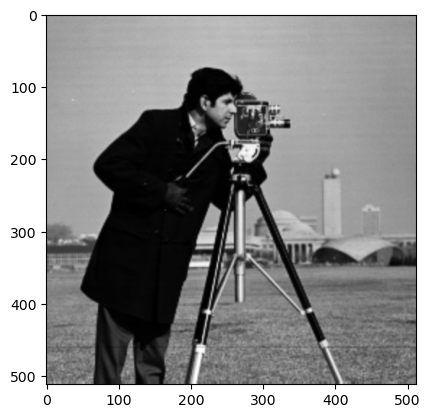

In [3]:
I = get_image("cameraman", size=512)
plt.imshow(I, cmap='gray');

In [4]:
play_with_image_kernels(I)

interactive(children=(Dropdown(description='kerneltype', options=(('Sobel', 'sobel'), ('Sharpen', 'sharpen'), …

You can create your own kernel! Run the following code, to enter your custom kernel and the code following that to apply this custom kernel to the image. 

Try changing the terms below, and see the effect of your custom kernel on the image. See if you can derive a new kernel for edge detection, sharpening, or simply to do any other fun effects on your image! 

Change the parameter 'size' if you'd like to have a bigger kernel. The default value is set at 3. Try to use an odd number for your kernel as it's generally the case. 

In [5]:
size = 3
sheet1 = from_array(np.zeros((size,size)))
sheet1

Sheet(cells=(Cell(column_end=2, column_start=0, row_end=2, row_start=0, squeeze_column=False, squeeze_row=Fals…

The kernel used is: 



,0,1,2
0,0.0,0.0,0.0
1,0.0,0.0,0.0
2,0.0,0.0,0.0


Input image and after convolution


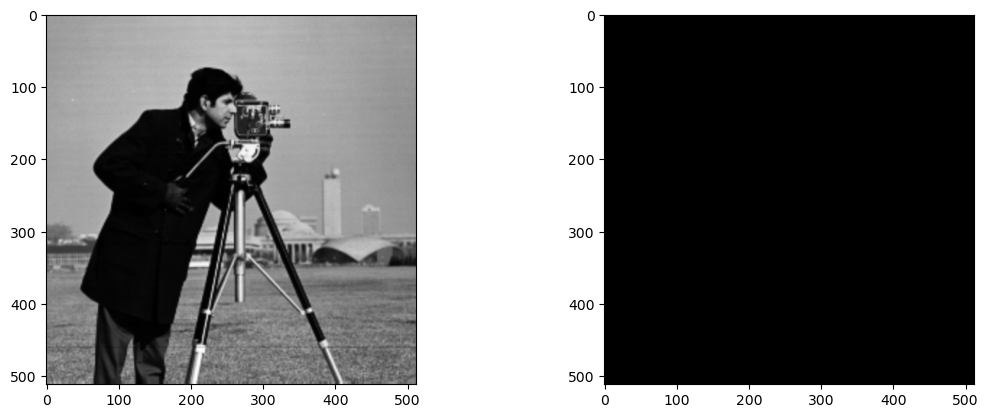

In [6]:
extract_kernel_and_convolve(I,sheet1)

 ### Convolution Theorem
 
The convolution theorem is one of the most important relationships in Fourier theory, and in its application to digital image processing. It can be stated as follows:

---
Consider functions a and b. Let A be the Fourier transform of a, and B be the Fourier transform of b. Then the Fourier transform of the product ab is the convolution of A and B. Call the result of this convolution C, then: 

<a id='equation_10'></a>
$
\begin{equation}
    C(h) = A(h)B(h)  \tag {10}\
\end{equation}
$

and 

<a id='equation_11'></a>
$
\begin{equation}
    c(x) = \sum_{y} a(y)b(x-y) = \mathcal{F}^{-1}\{C(h\}  \tag {11}\
\end{equation}
$

The product of two functions is simple - the values of the two functions are simply multiplied at every point.

The convolution of two functions is more complex. To convolve two functions, the first function must be superimposed on the second at every possible position, and multiplied by the value of the second function at that point. The convolution is the sum of all of these superpositions. The convolution theorem therefore allows us to perform such calculation much faster (in Fourier space) than the convolution itself (in Real space).

---

In rigorous terms, suppose $f(x,y)$ and $g(x,y)$ are two real-valued functions varying along $x$ and $y$ axes. Let $\tilde{F}(u,v)$ and $\tilde{G}(u,v)$ be the fourier transforms of $f(x,y)$ and $g(x,y)$ respectively, with $u$ and $v$ being the coordinates in frequency space. The convolution theorem states that: 
 
<a id='equation_12'></a>
$
\begin{equation}
     f(x,y) * g(x,y) =  \mathcal{F}^{-1} \{\tilde{F}(u,v) \cdot \tilde{G}(u,v)\} \tag {12}\
\end{equation}
$

where, 

$*$ refers to convolution and $\mathcal{F}^{-1}$ represents the inverse Fourier Transform operation.


To implement this practically to our Kernel examples above, we first need to compute the Fourier transforms of our input image and the kernel. These form the two functions $f$ and $g$. However, since the kernels we used before had a different size than our image, we also need to padd the kernel with zeros around it so that the sizes become equal. We then form the product of their Fourier transforms. Finally, we take the inverse Fourier transform of this product obtain the result of the original convolution. 

Try the following interactive to demonstrate the convolution theorem. The results appear in the following format: 


>[input image] >> [padded kernel] >> <i>Real Space</i> 

>[Fourier Transform of input image] >> [Fourier Transform of padded kernel] >> <i>Fourier Space</i> 

> [Final convolution] >>  >> <i>Real Space</i> 




In [7]:
convolution_theorem(I)

interactive(children=(Dropdown(description='kerneltype', options=(('Sharpen', 'sharpen'), ('Box blur', 'box'),…

Now compare the timings required to run both these algorithm. The images in the bottom appear in the following format:

>[input image] $\>$$\>$ [Convolution using FFT algorithm] 

>[input image] $\>$$\>$ [Convolution using convolve2D algorithm] 


In [8]:
compare_fft_convolve(I)

interactive(children=(Dropdown(description='kerneltype', options=(('Sharpen', 'sharpen'), ('Box blur', 'box'),…

You will find that the FFT algorithm is much faster when the kernel size selected is larger. 

[Prev: Convolutions](hri_practical01_part5.ipynb)    
[Next: CTF](hri_practical01_part7.ipynb)